# Image Classification Using CNNs and Traditional Machine Learning

## Objective
The goal of this project is to classify images into multiple categories using:
- A Random Forest baseline
- Multiple Convolutional Neural Network (CNN) architectures
- Regularization and stabilization techniques

## Experiments Performed
1. Random Forest Baseline
2. Baseline CNN
3. CNN with Data Augmentation
4. CNN with Class Weights
5. Stabilized CNN Architecture
6. CNN with L2 Regularization
7. K-Fold Cross Validation

## Evaluation Metrics
- Accuracy
- Confusion Matrix
- ROC-AUC Curves
- Classification Report

# Import Libraries and Set Random Seeds

This section imports all required libraries and ensures reproducibility by fixing random seeds across NumPy, TensorFlow, and Python.

In [1]:
# ============================================================================
# SET RANDOM SEEDS
# ============================================================================
import os
os.environ['PYTHONHASHSEED'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
np.random.seed(42)

import tensorflow as tf
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

import random
random.seed(42)

# ============================================================================
# IMPORTS
# ============================================================================
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

sns.set_style("darkgrid")
warnings.filterwarnings("ignore")

2026-05-12 10:03:47.569432: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778580227.986716      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778580228.098930      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778580229.141431      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778580229.141479      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778580229.141482      23 computation_placer.cc:177] computation placer alr

# Dataset Extraction

The uploaded ZIP file is extracted and checked to ensure the dataset structure is correct.

In [2]:
import os
import zipfile

# Kaggle datasets are mounted in /kaggle/input/
dataset_path = '/kaggle/input/'

print("Files in Kaggle input directory:")
for f in os.listdir(dataset_path):
    print(f"  {f}")

# Find your dataset folder (assuming you named it 'Final_images' or similar)
# Kaggle creates a folder with the dataset name
dataset_folder = os.path.join(dataset_path, '/kaggle/input/datasets/deeptasusanbeji/final-images')  # or whatever your dataset is named
# (Note: Kaggle converts spaces/underscores, usually to lowercase with hyphens)

print(f"\nContents of {dataset_folder}:")
if os.path.exists(dataset_folder):
    for item in os.listdir(dataset_folder):
        print(f"  {item}")
    
    # If your data is in a ZIP file within the dataset
    zip_file = os.path.join(dataset_folder, 'Final_images.zip')
    if os.path.exists(zip_file):
        with zipfile.ZipFile(zip_file, 'r') as zip_ref:
            print("\nExtracting ZIP...")
            zip_ref.extractall('/kaggle/working/')  # Extract to working directory
        print("✓ Extracted")
else:
    print(f"Dataset folder not found at {dataset_folder}")

# Check what's in the working directory now
print("\nContents of /kaggle/working/:")
for item in os.listdir('/kaggle/working/'):
    print(f"  {item}")

Files in Kaggle input directory:
  datasets

Contents of /kaggle/input/datasets/deeptasusanbeji/final-images:
  Final_images

Contents of /kaggle/working/:
  __notebook__.ipynb


# Configuration

This section defines:
- Image size
- Grayscale/RGB mode
- Regularization strength

In [3]:
USE_GRAYSCALE = True  # Set to True for grayscale, False for RGB
IMG_SIZE = 64
L2_STRENGTH = 0.0001  # L2 regularization strength

# Data Loading and Preprocessing

Images are:
- Loaded from class folders
- Resized to a fixed dimension
- Normalized to [0,1]
- Converted to grayscale if enabled

In [4]:
data_dir = "/kaggle/input/datasets/deeptasusanbeji/final-images/Final_images"
classes = sorted([
    c for c in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, c)) and c != ".DS_Store"
])

for c in classes:
    path = os.path.join(data_dir, c)
    print(f"{c}: {len(os.listdir(path))} images")

# Load images
data = []
labels = []

for label, class_name in enumerate(classes):
    class_path = os.path.join(data_dir, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        if USE_GRAYSCALE:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        else:
            img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        data.append(img)
        labels.append(label)

data = np.array(data, dtype=np.float32)
labels = np.array(labels)

# Reshape for grayscale (add channel dimension)
if USE_GRAYSCALE and len(data.shape) == 3:
    data = np.expand_dims(data, axis=-1)
    input_shape = (IMG_SIZE, IMG_SIZE, 1)
    print(f"\nGrayscale mode: {data.shape}")
else:
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
    print(f"\nRGB mode: {data.shape}")

print(f"Total data shape: {data.shape}, labels shape: {labels.shape}")

unique, counts = np.unique(labels, return_counts=True)
print("Class distribution:", dict(zip(classes, counts)))

Cell Periphery: 396 images
ER: 469 images
Mitochondria: 455 images
Nucleus: 567 images
Vacuole: 589 images

Grayscale mode: (2476, 64, 64, 1)
Total data shape: (2476, 64, 64, 1), labels shape: (2476,)
Class distribution: {'Cell Periphery': np.int64(396), 'ER': np.int64(469), 'Mitochondria': np.int64(455), 'Nucleus': np.int64(567), 'Vacuole': np.int64(589)}


# Dataset Splitting

The dataset is divided into:
- 70% Training
- 15% Validation
- 15% Testing

Stratified splitting is used to preserve class balance.

In [5]:
X = data
y = labels

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"\nTrain: {X_train.shape[0]}, Validation: {X_val.shape[0]}, Test: {X_test.shape[0]}")


Train: 1733, Validation: 371, Test: 372


# Data Leakage Verification

This section ensures there is no overlap between training, validation, and testing datasets.

In [6]:
# Check no overlapping images between sets
train_set = set(range(len(X_train)))
val_set = set(range(len(X_train), len(X_train) + len(X_val)))
test_set = set(range(len(X_train) + len(X_val), len(X)))

print(f"Train indices: {min(train_set)} to {max(train_set)}")
print(f"Val indices: {min(val_set)} to {max(val_set)}")
print(f"Test indices: {min(test_set)} to {max(test_set)}")

# Check for overlaps
overlap_train_val = train_set & val_set
overlap_val_test = val_set & test_set
overlap_train_test = train_set & test_set

print(f"\nOverlap Train-Val: {len(overlap_train_val)} images")
print(f"Overlap Val-Test: {len(overlap_val_test)} images")
print(f"Overlap Train-Test: {len(overlap_train_test)} images")

Train indices: 0 to 1732
Val indices: 1733 to 2103
Test indices: 2104 to 2475

Overlap Train-Val: 0 images
Overlap Val-Test: 0 images
Overlap Train-Test: 0 images


# Sample Images

A sample image from each class is displayed below.

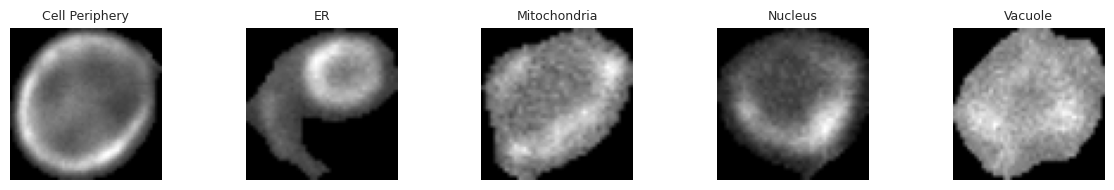

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(12, 2))
shown = set()
for i in range(len(data)):
    label = labels[i]
    if label not in shown:
        if USE_GRAYSCALE:
            axes[label].imshow(data[i, :, :, 0], cmap='gray')
        else:
            axes[label].imshow(data[i])
        axes[label].set_title(classes[label], fontsize=9)
        axes[label].axis("off")
        shown.add(label)
    if len(shown) == 5:
        break
plt.tight_layout()
mode_str = "grayscale" if USE_GRAYSCALE else "rgb"
plt.savefig(f"00_sample_images_{mode_str}.png", dpi=100, bbox_inches='tight')
plt.show()

# Helper Functions

The following reusable helper functions are defined for:
- ROC curve plotting
- Training visualization
- Confusion matrix plotting
- CNN model creation

In [8]:
# ============================================================================
# HELPER FUNCTION: PLOT ROC CURVE (MACRO-AVERAGE)
# ============================================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
def plot_roc_macro(y_true, y_pred_proba, model_name, filename):
    """Plot single macro-average ROC curve"""
    
    
    y_bin = label_binarize(y_true, classes=np.arange(len(classes)))
    
    # Calculate AUC for each class and get macro-average
    auc_scores = []
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        auc_scores.append(roc_auc)
    
    auc_macro = np.mean(auc_scores)
    
    # Plot using micro-average curve
    fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), y_pred_proba.ravel())
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr_micro, tpr_micro, lw=2.5, color='#e74c3c',
            label=f'AUC = {auc_macro:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("False Positive Rate", fontsize=11, fontweight='bold')
    ax.set_ylabel("True Positive Rate", fontsize=11, fontweight='bold')
    ax.set_title(f'{model_name}', fontsize=12, fontweight='bold')
    ax.legend(loc="lower right", fontsize=11)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=100, bbox_inches='tight')
    plt.show()
    
    return auc_macro

In [9]:
# ============================================================================
# TRAINING CURVES
# ============================================================================

def plot_training_curves(history, test_acc, title, filename):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')

    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')

    axes[1].axhline(
        y=test_acc,
        linestyle='--',
        label=f'Test Accuracy = {test_acc:.4f}'
    )

    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(filename, dpi=100, bbox_inches='tight')
    plt.show()


In [10]:
# ============================================================================
# CONFUSION MATRIX
# ============================================================================

def plot_conf_matrix(y_true, y_pred, title, filename):

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=classes,
        yticklabels=classes
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)

    plt.tight_layout()
    plt.savefig(filename, dpi=100, bbox_inches='tight')
    plt.show()

## CNN Model Builder (Baseline)

A reusable CNN model is defined for consistency across Model 1, 2, and 3.

- Used the same architecture for fair comparison across experiments  
- 3 convolution layers with increasing filters (32 → 64 → 128)  
- Batch normalisation after each convolution layer  
- Max pooling for downsampling  
- Fully connected dense layer with 128 neurons  
- Dropout is used to reduce overfitting  
- Softmax output layer for multi-class classification  

In [11]:
# ============================================================================
# CNN MODEL BUILDER
# ============================================================================

def create_baseline_cnn(input_shape):

    model = Sequential([

        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(64, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Conv2D(128, (3,3), activation='relu'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        Flatten(),

        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(5, activation='softmax')

    ])

    return model

## Stabilized CNN Model

A function is defined for stabilized CNN model which is an improved version of the baseline CNN.

- Uses two convolution layers per block instead of one to learn richer features  
- Batch normalization is applied after each convolution layer for stable training  
- Max pooling is used after feature extraction stages to reduce spatial size  
- Dropout is added at different stages to reduce overfitting  
- Global Average Pooling is used instead of Flatten to reduce model complexity  
- Optional L2 regularization is included to penalize large weights  
- Final dense layer has 256 neurons before classification  
- Output layer uses softmax for 5-class classification  

In [12]:
# ============================================================================
# STABILIZED CNN
# ============================================================================

def create_stabilized_cnn(input_shape, use_l2=False):

    regularizer = l2(L2_STRENGTH) if use_l2 else None

    model = tf.keras.Sequential()

    model.add(tf.keras.layers.Input(shape=input_shape))

    model.add(Conv2D(
        32, (3,3),
        padding='same',
        activation='relu',
        kernel_regularizer=regularizer
    ))

    model.add(BatchNormalization())

    model.add(Conv2D(
        32, (3,3),
        padding='same',
        activation='relu',
        kernel_regularizer=regularizer
    ))

    model.add(BatchNormalization())
    model.add(MaxPooling2D(2))
    model.add(Dropout(0.2))

    model.add(Conv2D(
        64, (3,3),
        padding='same',
        activation='relu',
        kernel_regularizer=regularizer
    ))

    model.add(BatchNormalization())

    model.add(Conv2D(
        64, (3,3),
        padding='same',
        activation='relu',
        kernel_regularizer=regularizer
    ))

    model.add(BatchNormalization())
    model.add(MaxPooling2D(2))
    model.add(Dropout(0.3))

    model.add(Conv2D(
        128, (3,3),
        padding='same',
        activation='relu',
        kernel_regularizer=regularizer
    ))

    model.add(BatchNormalization())

    model.add(Conv2D(
        128, (3,3),
        padding='same',
        activation='relu',
        kernel_regularizer=regularizer
    ))

    model.add(BatchNormalization())

    model.add(GlobalAveragePooling2D())

    model.add(Dense(
        256,
        activation='relu',
        kernel_regularizer=regularizer
    ))

    model.add(Dropout(0.3))

    model.add(Dense(5, activation='softmax'))

    return model

# Random Forest Baseline

A traditional machine learning baseline is trained using flattened image features.
This provides a comparison against deep learning approaches.


RANDOM FOREST BASELINE
Train Accuracy: 0.9965
Validation Accuracy: 0.8248
Test Accuracy: 0.8387

Classification Report:
                precision    recall  f1-score   support

Cell Periphery       0.76      0.59      0.67        59
            ER       0.88      0.86      0.87        71
  Mitochondria       0.75      0.69      0.72        68
       Nucleus       0.97      1.00      0.98        85
       Vacuole       0.79      0.94      0.86        89

      accuracy                           0.84       372
     macro avg       0.83      0.82      0.82       372
  weighted avg       0.84      0.84      0.83       372



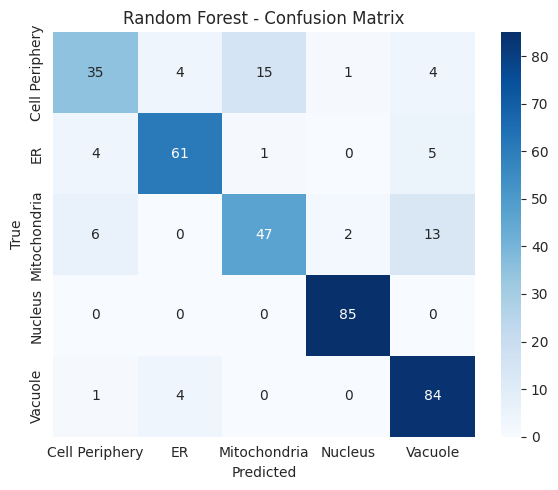

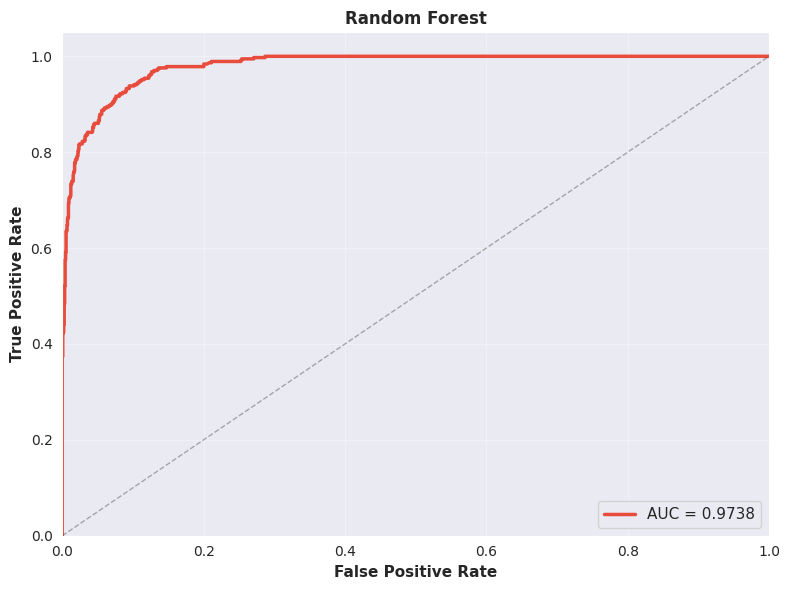

In [13]:
# ============================================================================
# RANDOM FOREST BASELINE
# ============================================================================

print("\n" + "="*70)
print("RANDOM FOREST BASELINE")
print("="*70)

# Flatten image tensors
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train_flat, y_train)

# Accuracy
rf_train_acc = rf_model.score(X_train_flat, y_train)
rf_val_acc = rf_model.score(X_val_flat, y_val)
rf_test_acc = rf_model.score(X_test_flat, y_test)

print(f"Train Accuracy: {rf_train_acc:.4f}")
print(f"Validation Accuracy: {rf_val_acc:.4f}")
print(f"Test Accuracy: {rf_test_acc:.4f}")

# Predictions
rf_y_pred = rf_model.predict(X_test_flat)
rf_y_pred_proba = rf_model.predict_proba(X_test_flat)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_y_pred,
    target_names=classes
))

# Confusion matrix
plot_conf_matrix(
    y_test,
    rf_y_pred,
    "Random Forest - Confusion Matrix",
    f"01_random_forest_confusion_matrix_{mode_str}.png"
)

# ROC Curve
rf_auc_macro = plot_roc_macro(y_test, rf_y_pred_proba, "Random Forest", f"01_rf_roc_{mode_str}.png")

# Model 1 — Baseline CNN

The first CNN model serves as the baseline deep learning architecture.
It consists of convolution layers, batch normalization, max pooling, and dropout regularization.


MODEL 1: BASELINE CNN


I0000 00:00:1778580295.826077      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778580295.832465      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/20


2026-05-12 10:04:57.954472: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
I0000 00:00:1778580300.895170     117 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-12 10:05:06.387852: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:var

55/55 - 9s - 161ms/step - accuracy: 0.6722 - loss: 1.1241 - val_accuracy: 0.3558 - val_loss: 4.5907
Epoch 2/20
55/55 - 1s - 15ms/step - accuracy: 0.8009 - loss: 0.5796 - val_accuracy: 0.2992 - val_loss: 6.4554
Epoch 3/20
55/55 - 1s - 15ms/step - accuracy: 0.8361 - loss: 0.4720 - val_accuracy: 0.2372 - val_loss: 9.2256
Epoch 4/20
55/55 - 1s - 15ms/step - accuracy: 0.8529 - loss: 0.4167 - val_accuracy: 0.2372 - val_loss: 7.9179
Epoch 5/20
55/55 - 1s - 15ms/step - accuracy: 0.8898 - loss: 0.3294 - val_accuracy: 0.2453 - val_loss: 8.1748
Epoch 6/20
55/55 - 1s - 15ms/step - accuracy: 0.8915 - loss: 0.2722 - val_accuracy: 0.3639 - val_loss: 6.2584
Epoch 7/20
55/55 - 1s - 15ms/step - accuracy: 0.9083 - loss: 0.2544 - val_accuracy: 0.3585 - val_loss: 5.9607
Epoch 8/20
55/55 - 1s - 15ms/step - accuracy: 0.9186 - loss: 0.2491 - val_accuracy: 0.3639 - val_loss: 6.8502
Epoch 9/20
55/55 - 1s - 15ms/step - accuracy: 0.9088 - loss: 0.2652 - val_accuracy: 0.4259 - val_loss: 5.7379
Epoch 10/20
55/55 - 

2026-05-12 10:05:22.244041: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


12/12 - 0s - 24ms/step
12/12 - 0s - 7ms/step
Test Accuracy: 0.8817

Classification Report:
                precision    recall  f1-score   support

Cell Periphery       0.94      0.78      0.85        59
            ER       1.00      0.90      0.95        71
  Mitochondria       0.67      0.96      0.79        68
       Nucleus       0.92      1.00      0.96        85
       Vacuole       0.97      0.76      0.86        89

      accuracy                           0.88       372
     macro avg       0.90      0.88      0.88       372
  weighted avg       0.91      0.88      0.88       372



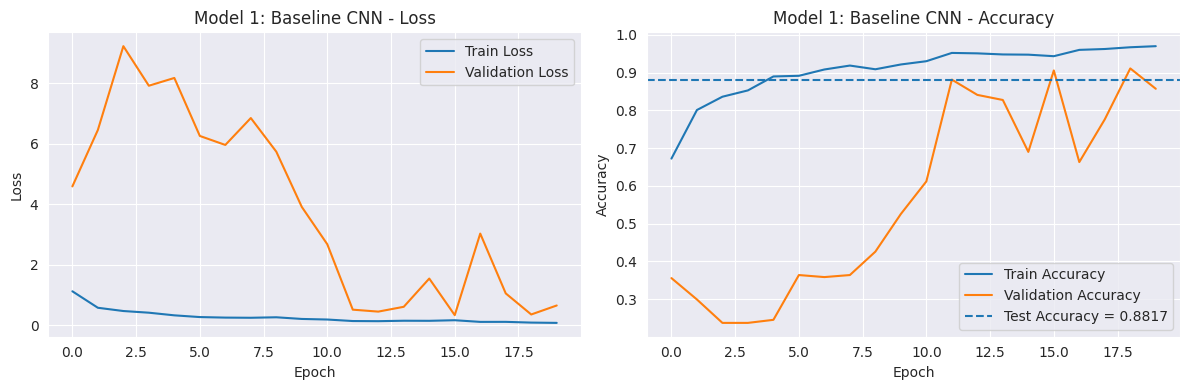

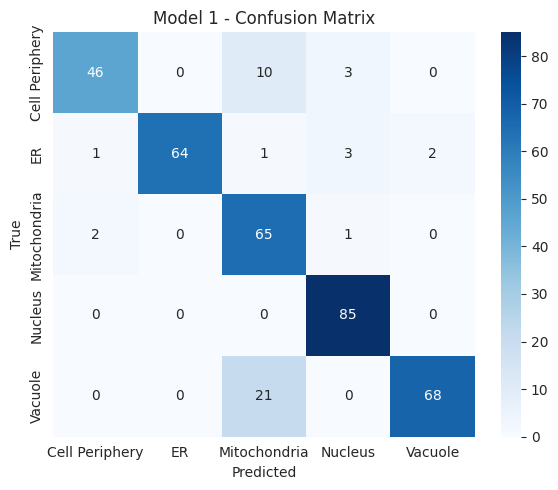

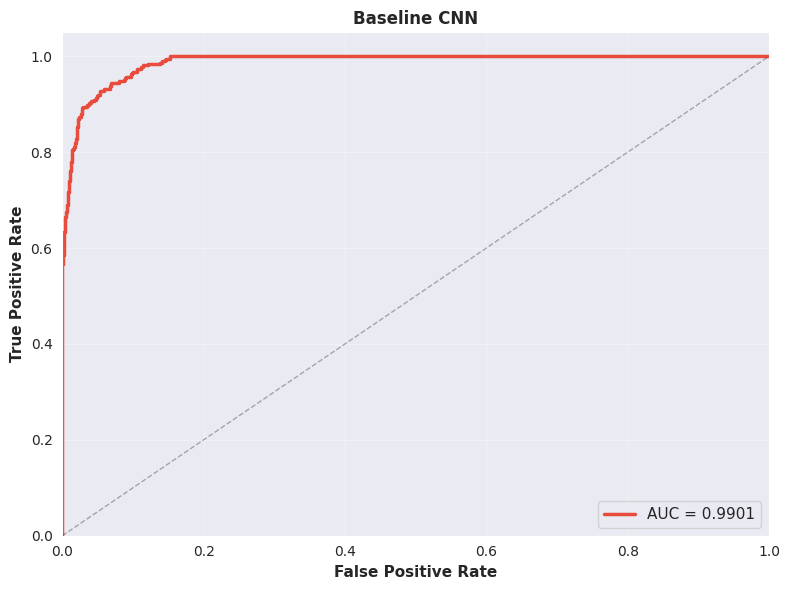

In [14]:
# ============================================================================
# MODEL 1: BASELINE CNN
# ============================================================================

print("\n" + "="*70)
print("MODEL 1: BASELINE CNN")
print("="*70)

# Create model
model1 = create_baseline_cnn(input_shape)

# Compile
model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history1 = model1.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    verbose=2
)

# Evaluate
test_loss1, test_acc1 = model1.evaluate(X_test, y_test, verbose=2)

y_pred1 = np.argmax(model1.predict(X_test, verbose=2), axis=1)
y_pred1_proba = model1.predict(X_test, verbose=2)

print(f"Test Accuracy: {test_acc1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred1,
    target_names=classes
))

# Training curves
plot_training_curves(
    history1,
    test_acc1,
    "Model 1: Baseline CNN",
    f"02_model1_curves_{mode_str}.png"
)

# Confusion matrix
plot_conf_matrix(
    y_test,
    y_pred1,
    "Model 1 - Confusion Matrix",
    f"02_model1_confusion_matrix_{mode_str}.png"
)

# ROC curve
auc1_macro = plot_roc_macro(y_test, y_pred1_proba, "Baseline CNN", f"02_model1_roc_{mode_str}.png")

# Model 2 — CNN with Data Augmentation

To improve generalization performance and reduce overfitting,
data augmentation techniques are applied during training.


MODEL 2: DATA AUGMENTATION
Epoch 1/20


2026-05-12 10:05:28.417644: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


55/55 - 4s - 82ms/step - accuracy: 0.6249 - loss: 1.3430 - val_accuracy: 0.2372 - val_loss: 4.1008
Epoch 2/20
55/55 - 2s - 31ms/step - accuracy: 0.7576 - loss: 0.7076 - val_accuracy: 0.2372 - val_loss: 9.2859
Epoch 3/20
55/55 - 2s - 32ms/step - accuracy: 0.7796 - loss: 0.6184 - val_accuracy: 0.2372 - val_loss: 10.2346
Epoch 4/20
55/55 - 2s - 30ms/step - accuracy: 0.8050 - loss: 0.5936 - val_accuracy: 0.2372 - val_loss: 9.7658
Epoch 5/20
55/55 - 2s - 30ms/step - accuracy: 0.8044 - loss: 0.5362 - val_accuracy: 0.2480 - val_loss: 8.1103
Epoch 6/20
55/55 - 2s - 30ms/step - accuracy: 0.8067 - loss: 0.5568 - val_accuracy: 0.2534 - val_loss: 7.4403
Epoch 7/20
55/55 - 2s - 30ms/step - accuracy: 0.8482 - loss: 0.4443 - val_accuracy: 0.2668 - val_loss: 8.7874
Epoch 8/20
55/55 - 2s - 30ms/step - accuracy: 0.8355 - loss: 0.4545 - val_accuracy: 0.3288 - val_loss: 4.9110
Epoch 9/20
55/55 - 2s - 32ms/step - accuracy: 0.8430 - loss: 0.4908 - val_accuracy: 0.4690 - val_loss: 1.5612
Epoch 10/20
55/55 - 

2026-05-12 10:06:01.200051: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


12/12 - 0s - 26ms/step
12/12 - 0s - 8ms/step
Test Accuracy: 0.6909

Classification Report:
                precision    recall  f1-score   support

Cell Periphery       1.00      0.44      0.61        59
            ER       1.00      0.77      0.87        71
  Mitochondria       0.54      0.59      0.56        68
       Nucleus       1.00      0.56      0.72        85
       Vacuole       0.52      0.99      0.68        89

      accuracy                           0.69       372
     macro avg       0.81      0.67      0.69       372
  weighted avg       0.80      0.69      0.69       372



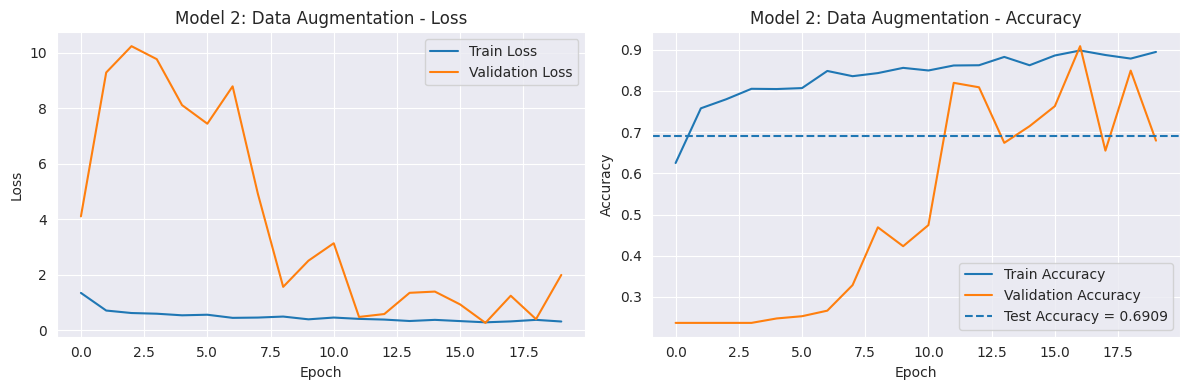

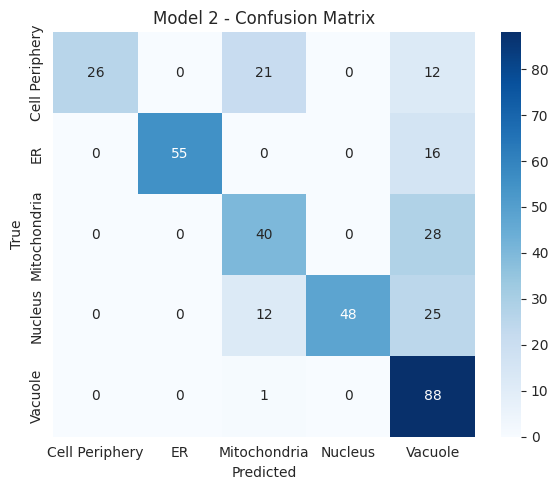

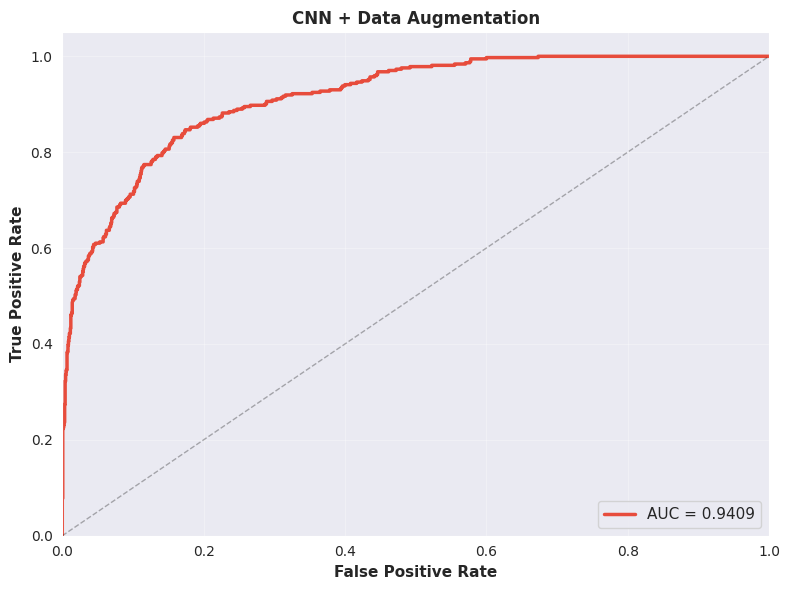

In [15]:
# ============================================================================
# MODEL 2: DATA AUGMENTATION
# ============================================================================

print("\n" + "="*70)
print("MODEL 2: DATA AUGMENTATION")
print("="*70)

# Create model
model2 = create_baseline_cnn(input_shape)

# Compile
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

# Train
history2 = model2.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=20,
    verbose=2
)

# Evaluate
test_loss2, test_acc2 = model2.evaluate(X_test, y_test, verbose=2)

y_pred2 = np.argmax(model2.predict(X_test, verbose=2), axis=1)
y_pred2_proba = model2.predict(X_test, verbose=2)

print(f"Test Accuracy: {test_acc2:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred2,
    target_names=classes
))

# Training curves
plot_training_curves(
    history2,
    test_acc2,
    "Model 2: Data Augmentation",
    f"03_model2_curves_{mode_str}.png"
)

# Confusion matrix
plot_conf_matrix(
    y_test,
    y_pred2,
    "Model 2 - Confusion Matrix",
    f"03_model2_confusion_matrix_{mode_str}.png"
)

# ROC curve
auc2_macro = plot_roc_macro(y_test, y_pred2_proba, "CNN + Data Augmentation", f"03_model2_roc_{mode_str}.png")

# Model 3 — CNN with Class Weights

In this model, class weights are introduced to address class imbalance.
This helps the model give more importance to underrepresented classes during training.


MODEL 3: CLASS WEIGHTS
Class Weights:
{0: np.float64(1.2512635379061372), 1: np.float64(1.0567073170731707), 2: np.float64(1.0865203761755486), 3: np.float64(0.8730478589420655), 4: np.float64(0.8412621359223301)}
Epoch 1/20


2026-05-12 10:06:07.540059: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


55/55 - 5s - 84ms/step - accuracy: 0.5788 - loss: 1.6421 - val_accuracy: 0.2372 - val_loss: 3.2358
Epoch 2/20
55/55 - 2s - 31ms/step - accuracy: 0.6896 - loss: 0.9017 - val_accuracy: 0.3208 - val_loss: 5.8813
Epoch 3/20
55/55 - 2s - 31ms/step - accuracy: 0.7149 - loss: 0.8177 - val_accuracy: 0.2615 - val_loss: 6.7108
Epoch 4/20
55/55 - 2s - 32ms/step - accuracy: 0.7530 - loss: 0.7175 - val_accuracy: 0.2453 - val_loss: 8.6980
Epoch 5/20
55/55 - 2s - 32ms/step - accuracy: 0.7663 - loss: 0.6413 - val_accuracy: 0.2588 - val_loss: 6.4678
Epoch 6/20
55/55 - 2s - 31ms/step - accuracy: 0.7842 - loss: 0.6174 - val_accuracy: 0.3504 - val_loss: 8.7387
Epoch 7/20
55/55 - 2s - 32ms/step - accuracy: 0.8229 - loss: 0.5291 - val_accuracy: 0.2507 - val_loss: 7.9441
Epoch 8/20
55/55 - 2s - 31ms/step - accuracy: 0.7957 - loss: 0.6469 - val_accuracy: 0.5310 - val_loss: 2.5996
Epoch 9/20
55/55 - 2s - 32ms/step - accuracy: 0.8021 - loss: 0.5555 - val_accuracy: 0.3612 - val_loss: 5.6936
Epoch 10/20
55/55 - 2

2026-05-12 10:06:40.905280: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


12/12 - 0s - 25ms/step
12/12 - 0s - 8ms/step
Test Accuracy: 0.3710

Classification Report:
                precision    recall  f1-score   support

Cell Periphery       1.00      0.03      0.07        59
            ER       0.00      0.00      0.00        71
  Mitochondria       0.24      1.00      0.39        68
       Nucleus       1.00      0.69      0.82        85
       Vacuole       0.35      0.10      0.16        89

      accuracy                           0.37       372
     macro avg       0.52      0.37      0.29       372
  weighted avg       0.51      0.37      0.31       372



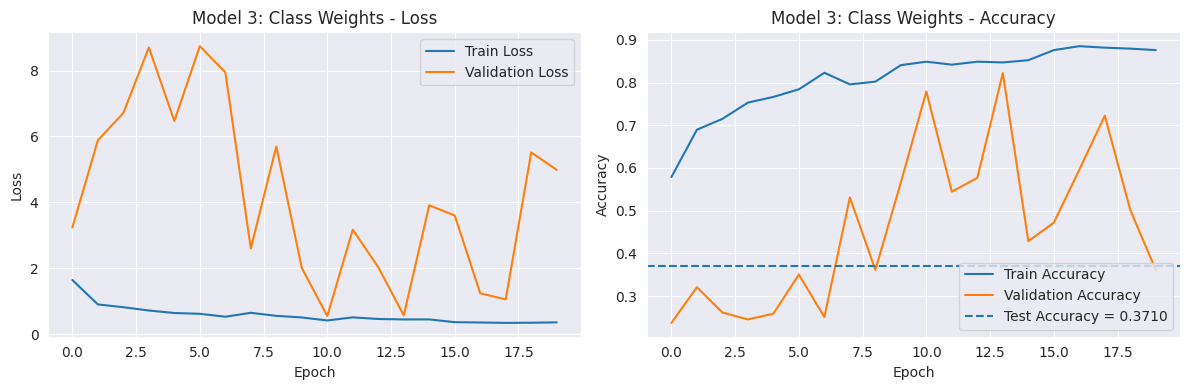

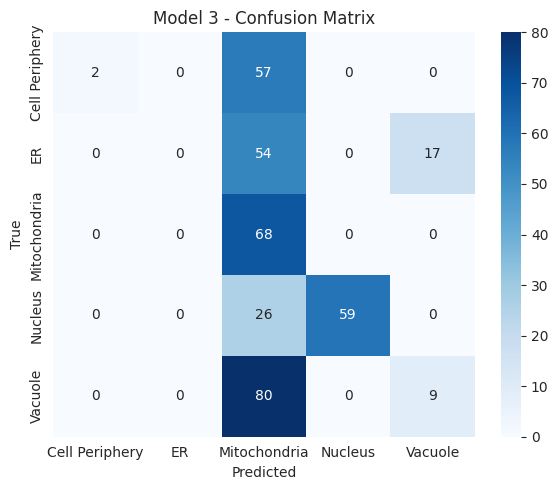

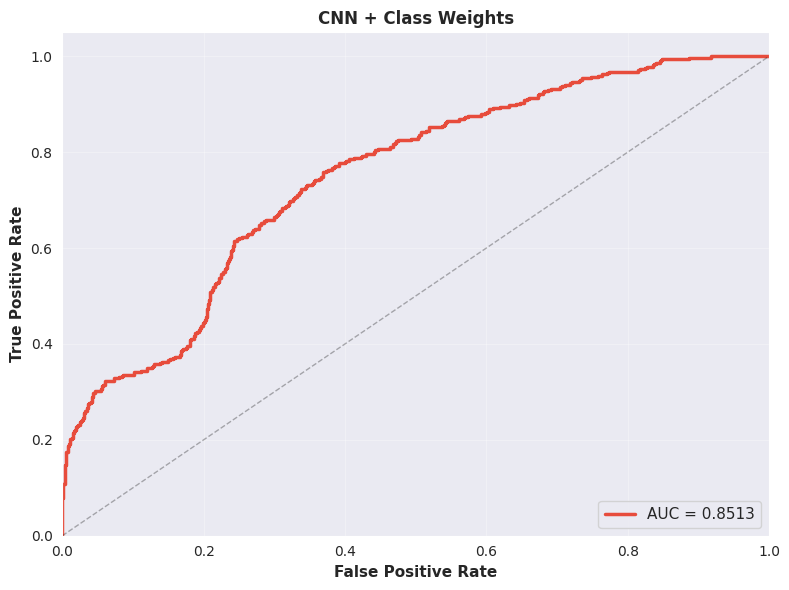

In [16]:
# ============================================================================
# MODEL 3: CLASS WEIGHTS
# ============================================================================

print("\n" + "="*70)
print("MODEL 3: CLASS WEIGHTS")
print("="*70)

# Create model
model3 = create_baseline_cnn(input_shape)

# Compile
model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Compute class weights
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print("Class Weights:")
print(class_weights)

# Train
history3 = model3.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=20,
    class_weight=class_weights,
    verbose=2
)

# Evaluate
test_loss3, test_acc3 = model3.evaluate(X_test, y_test, verbose=0)

y_pred3 = np.argmax(model3.predict(X_test, verbose=2), axis=1)
y_pred3_proba = model3.predict(X_test, verbose=2)

print(f"Test Accuracy: {test_acc3:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred3,
    target_names=classes
))

# Training curves
plot_training_curves(
    history3,
    test_acc3,
    "Model 3: Class Weights",
    f"04_model3_curves_{mode_str}.png"
)

# Confusion matrix
plot_conf_matrix(
    y_test,
    y_pred3,
    "Model 3 - Confusion Matrix",
    f"04_model3_confusion_matrix_{mode_str}.png"
)

# ROC curve
auc3_macro = plot_roc_macro(y_test, y_pred3_proba, "CNN + Class Weights", f"04_model3_roc_{mode_str}.png")

# Model 4 — Stabilized CNN Architecture

This model introduces a deeper and more stable CNN architecture with:
- Additional convolution layers
- Global average pooling
- Dropout regularization
- Learning rate scheduling
- Early stopping

These modifications improve training stability and reduce overfitting.


MODEL 4: STABILIZED CNN
Epoch 1/50


E0000 00:00:1778580407.377182      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_3_1/dropout_3_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-05-12 10:06:50.098569: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


55/55 - 7s - 131ms/step - accuracy: 0.6734 - loss: 0.8644 - val_accuracy: 0.1833 - val_loss: 2.6668 - learning_rate: 5.0000e-04
Epoch 2/50
55/55 - 2s - 42ms/step - accuracy: 0.8119 - loss: 0.5299 - val_accuracy: 0.1833 - val_loss: 4.0181 - learning_rate: 5.0000e-04
Epoch 3/50
55/55 - 2s - 42ms/step - accuracy: 0.8454 - loss: 0.4168 - val_accuracy: 0.1833 - val_loss: 3.3609 - learning_rate: 5.0000e-04
Epoch 4/50
55/55 - 2s - 41ms/step - accuracy: 0.8788 - loss: 0.3296 - val_accuracy: 0.2372 - val_loss: 5.1140 - learning_rate: 5.0000e-04
Epoch 5/50
55/55 - 2s - 41ms/step - accuracy: 0.8944 - loss: 0.3101 - val_accuracy: 0.2965 - val_loss: 4.8217 - learning_rate: 5.0000e-04
Epoch 6/50
55/55 - 2s - 42ms/step - accuracy: 0.9042 - loss: 0.2961 - val_accuracy: 0.2830 - val_loss: 6.5051 - learning_rate: 5.0000e-04
Epoch 7/50
55/55 - 2s - 41ms/step - accuracy: 0.9134 - loss: 0.2683 - val_accuracy: 0.1968 - val_loss: 5.2444 - learning_rate: 2.5000e-04
Epoch 8/50
55/55 - 2s - 41ms/step - accuracy

2026-05-12 10:08:28.324506: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


12/12 - 0s - 38ms/step
12/12 - 0s - 9ms/step
Test Accuracy: 0.9247

Classification Report:
                precision    recall  f1-score   support

Cell Periphery       0.98      0.73      0.83        59
            ER       0.99      0.93      0.96        71
  Mitochondria       0.76      0.99      0.86        68
       Nucleus       1.00      0.99      0.99        85
       Vacuole       0.94      0.94      0.94        89

      accuracy                           0.92       372
     macro avg       0.93      0.92      0.92       372
  weighted avg       0.94      0.92      0.92       372



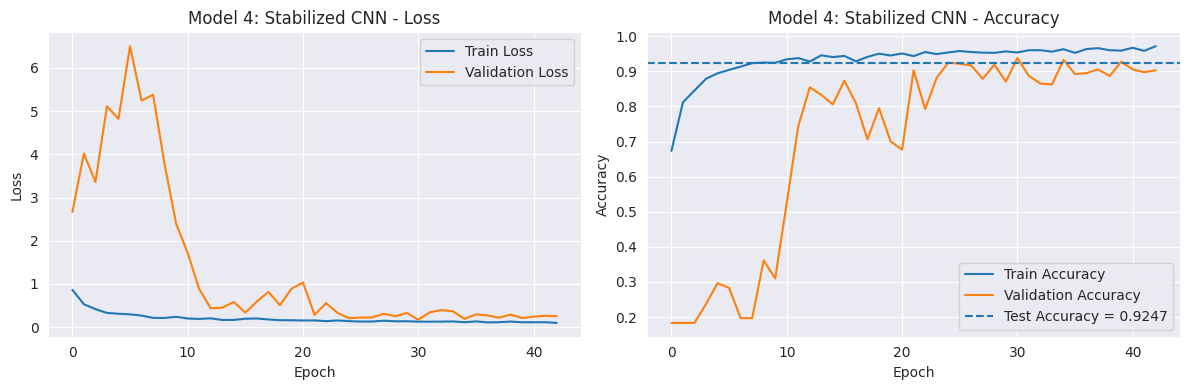

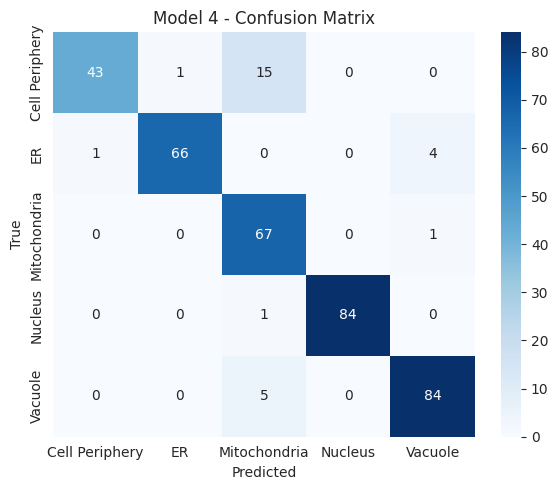

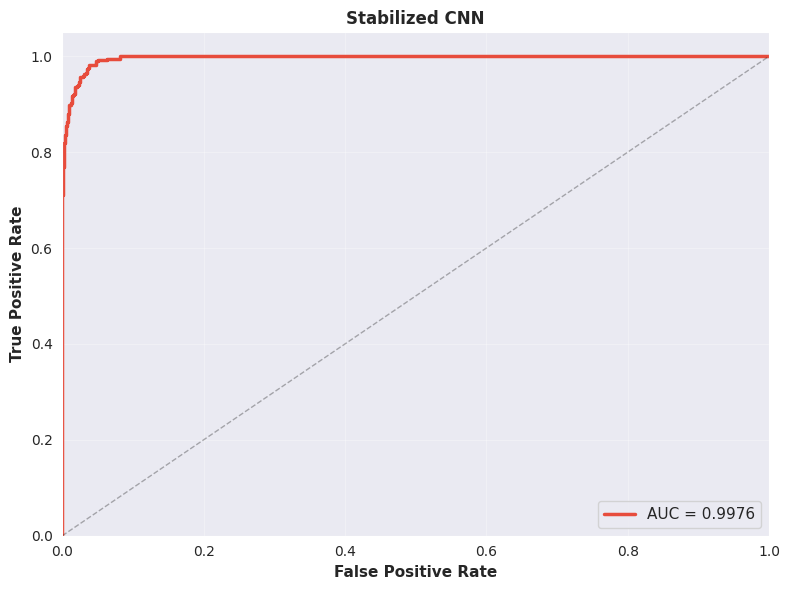

In [17]:
# ============================================================================
# MODEL 4: STABILIZED CNN
# ============================================================================

print("\n" + "="*70)
print("MODEL 4: STABILIZED CNN")
print("="*70)

# Create model
model4 = create_stabilized_cnn(input_shape)

# Compile
model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=12,
        restore_best_weights=True,
        verbose=0
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=0
    )

]

# Train
history4 = model4.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=50,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=2
)

# Evaluate
test_loss4, test_acc4 = model4.evaluate(X_test, y_test, verbose=0)

y_pred4 = np.argmax(model4.predict(X_test, verbose=2), axis=1)
y_pred4_proba = model4.predict(X_test, verbose=2)

print(f"Test Accuracy: {test_acc4:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred4,
    target_names=classes
))

# Training curves
plot_training_curves(
    history4,
    test_acc4,
    "Model 4: Stabilized CNN",
    f"05_model4_curves_{mode_str}.png"
)

# Confusion matrix
plot_conf_matrix(
    y_test,
    y_pred4,
    "Model 4 - Confusion Matrix",
    f"05_model4_confusion_matrix_{mode_str}.png"
)

# ROC curve
auc4_macro = plot_roc_macro(y_test, y_pred4_proba, "Stabilized CNN", f"05_model4_roc_{mode_str}.png")

# Model 5 — CNN with L2 Regularization

The final model applies L2 regularization to the stabilized CNN architecture.
L2 regularization penalizes large weights and helps improve generalization performance by reducing overfitting.


MODEL 5: L2 REGULARIZATION
Epoch 1/50


E0000 00:00:1778580514.923900      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_4_1/dropout_6_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-05-12 10:08:37.543784: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


55/55 - 7s - 135ms/step - accuracy: 0.6688 - loss: 0.9287 - val_accuracy: 0.1833 - val_loss: 2.2032 - learning_rate: 5.0000e-04
Epoch 2/50
55/55 - 2s - 42ms/step - accuracy: 0.8194 - loss: 0.5605 - val_accuracy: 0.1833 - val_loss: 4.5747 - learning_rate: 5.0000e-04
Epoch 3/50
55/55 - 2s - 42ms/step - accuracy: 0.8754 - loss: 0.4444 - val_accuracy: 0.2561 - val_loss: 4.7468 - learning_rate: 5.0000e-04
Epoch 4/50
55/55 - 2s - 42ms/step - accuracy: 0.8857 - loss: 0.3792 - val_accuracy: 0.1833 - val_loss: 4.6913 - learning_rate: 5.0000e-04
Epoch 5/50
55/55 - 2s - 42ms/step - accuracy: 0.8823 - loss: 0.3716 - val_accuracy: 0.1833 - val_loss: 5.4943 - learning_rate: 5.0000e-04
Epoch 6/50
55/55 - 2s - 42ms/step - accuracy: 0.8852 - loss: 0.3697 - val_accuracy: 0.2372 - val_loss: 5.3042 - learning_rate: 5.0000e-04
Epoch 7/50
55/55 - 2s - 42ms/step - accuracy: 0.9129 - loss: 0.3001 - val_accuracy: 0.2156 - val_loss: 4.3840 - learning_rate: 2.5000e-04
Epoch 8/50
55/55 - 2s - 42ms/step - accuracy

2026-05-12 10:10:03.790656: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


12/12 - 0s - 36ms/step
12/12 - 0s - 8ms/step
Test Accuracy: 0.9597

Classification Report:
                precision    recall  f1-score   support

Cell Periphery       0.93      0.92      0.92        59
            ER       1.00      0.96      0.98        71
  Mitochondria       0.90      0.94      0.92        68
       Nucleus       0.96      1.00      0.98        85
       Vacuole       1.00      0.97      0.98        89

      accuracy                           0.96       372
     macro avg       0.96      0.96      0.96       372
  weighted avg       0.96      0.96      0.96       372



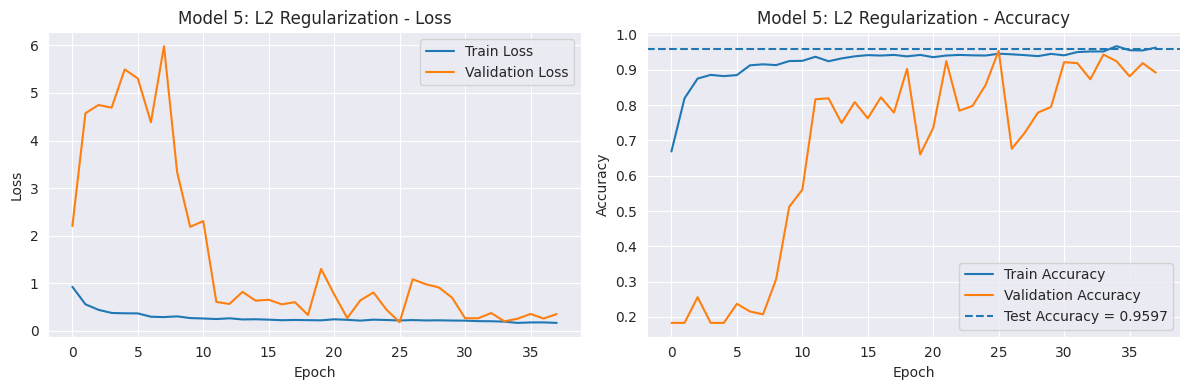

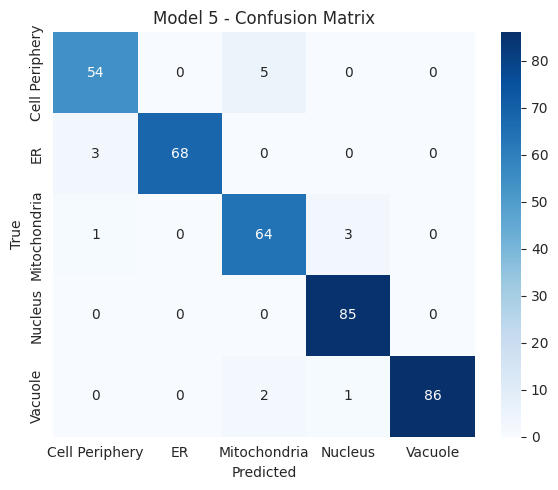

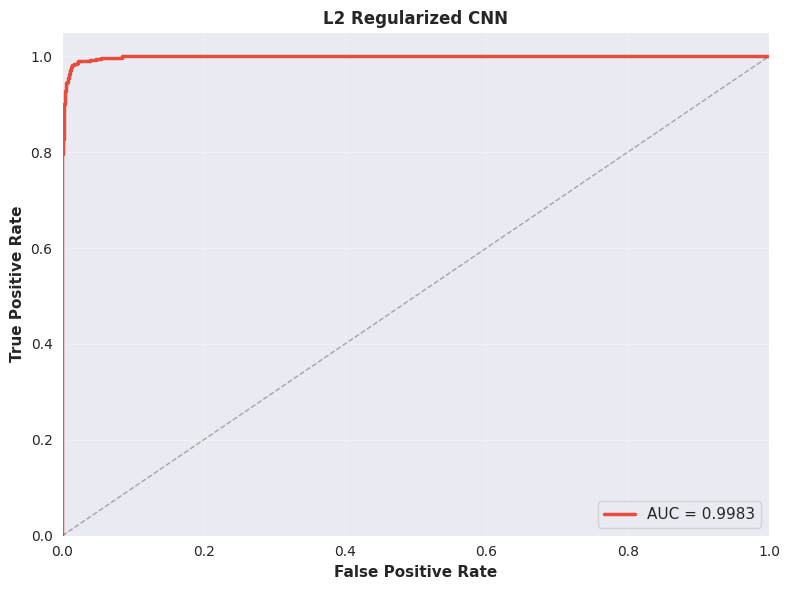

In [18]:
# ============================================================================
# MODEL 5: L2 REGULARIZATION
# ============================================================================

print("\n" + "="*70)
print("MODEL 5: L2 REGULARIZATION")
print("="*70)

# Create model
model5 = create_stabilized_cnn(
    input_shape,
    use_l2=True
)

# Compile
model5.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history5 = model5.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=50,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=2
)

# Evaluate
test_loss5, test_acc5 = model5.evaluate(X_test, y_test, verbose=2)

y_pred5 = np.argmax(model5.predict(X_test, verbose=2), axis=1)
y_pred5_proba = model5.predict(X_test, verbose=2)

print(f"Test Accuracy: {test_acc5:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred5,
    target_names=classes
))

# Training curves
plot_training_curves(
    history5,
    test_acc5,
    "Model 5: L2 Regularization",
    f"06_model5_curves_{mode_str}.png"
)

# Confusion matrix
plot_conf_matrix(
    y_test,
    y_pred5,
    "Model 5 - Confusion Matrix",
    f"06_model5_confusion_matrix_{mode_str}.png"
)

# ROC curve
auc5_macro = plot_roc_macro(y_test, y_pred5_proba, "L2 Regularized CNN", f"06_model5_roc_{mode_str}.png")

# K-Fold Cross-Validation

To evaluate the stability of the CNN models, 5-fold cross-validation was performed in two settings:

1. Stabilized CNN without L2 regularization  
2. Stabilized CNN with L2 regularization  

In each case:
- The training data was split into 5 folds
- A fresh model was created for each fold
- The model was trained on 4 folds and validated on the remaining fold
- Validation accuracy was recorded for each run

This allows comparison of how L2 regularization affects the consistency and generalization of the stabilized CNN.

In [19]:
# ============================================================================
# 5-FOLD CROSS-VALIDATION ON STABILIZED CNN
# ============================================================================

from sklearn.model_selection import StratifiedKFold

print("\n" + "="*70)
print("5-FOLD CROSS-VALIDATION ON STABILIZED CNN")
print("="*70)

# ---------------------------------------------------------------------------
# K-FOLD CONFIGURATION
# ---------------------------------------------------------------------------

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_scores = []

print("\nTraining 5 independent models...\n")

# ---------------------------------------------------------------------------
# TRAIN ACROSS FOLDS
# ---------------------------------------------------------------------------

for fold_num, (train_idx, val_idx) in enumerate(
    kfold.split(X_train, y_train),
    start=1
):

    print(f"Fold {fold_num}/5")

    # Clear TensorFlow session
    tf.keras.backend.clear_session()

    # -----------------------------------------------------------------------
    # SPLIT DATA
    # -----------------------------------------------------------------------

    X_fold_train = X_train[train_idx]
    X_fold_val = X_train[val_idx]

    y_fold_train = y_train[train_idx]
    y_fold_val = y_train[val_idx]

    print(f"  Train: {len(X_fold_train)}")
    print(f"  Validation: {len(X_fold_val)}")

    # -----------------------------------------------------------------------
    # CREATE MODEL
    # -----------------------------------------------------------------------

    fold_model = create_stabilized_cnn(input_shape)

    fold_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # -----------------------------------------------------------------------
    # TRAIN MODEL
    # -----------------------------------------------------------------------

    history = fold_model.fit(
        X_fold_train,
        y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=50,
        batch_size=32,
        verbose=2
    )

    # -----------------------------------------------------------------------
    # EVALUATE MODEL
    # -----------------------------------------------------------------------

    _, fold_acc = fold_model.evaluate(
        X_fold_val,
        y_fold_val,
        verbose=2
    )

    fold_scores.append(fold_acc)

    print(f"  Accuracy: {fold_acc:.4f}")

# ---------------------------------------------------------------------------
# FINAL RESULTS
# ---------------------------------------------------------------------------

mean_acc_1 = np.mean(fold_scores)
std_acc_1 = np.std(fold_scores)

print("\n" + "="*70)
print("FINAL CROSS-VALIDATION RESULTS")
print("="*70)

print(f"Mean Accuracy: {mean_acc_1:.4f}")
print(f"Standard Deviation: {std_acc_1:.4f}")
print(f"Minimum Accuracy: {np.min(fold_scores):.4f}")
print(f"Maximum Accuracy: {np.max(fold_scores):.4f}")


5-FOLD CROSS-VALIDATION ON STABILIZED CNN

Training 5 independent models...

Fold 1/5
  Train: 1386
  Validation: 347
Epoch 1/50


E0000 00:00:1778580611.142002      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-05-12 10:10:12.813244: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


44/44 - 6s - 144ms/step - accuracy: 0.6869 - loss: 0.8156 - val_accuracy: 0.1844 - val_loss: 1.9212
Epoch 2/50
44/44 - 1s - 30ms/step - accuracy: 0.8254 - loss: 0.4793 - val_accuracy: 0.1844 - val_loss: 2.2771
Epoch 3/50
44/44 - 1s - 29ms/step - accuracy: 0.8600 - loss: 0.3853 - val_accuracy: 0.1412 - val_loss: 2.1658
Epoch 4/50
44/44 - 1s - 29ms/step - accuracy: 0.8831 - loss: 0.3197 - val_accuracy: 0.1585 - val_loss: 3.6796
Epoch 5/50
44/44 - 1s - 29ms/step - accuracy: 0.9084 - loss: 0.2564 - val_accuracy: 0.1758 - val_loss: 4.5807
Epoch 6/50
44/44 - 1s - 29ms/step - accuracy: 0.9170 - loss: 0.2347 - val_accuracy: 0.1585 - val_loss: 7.0315
Epoch 7/50
44/44 - 1s - 29ms/step - accuracy: 0.9322 - loss: 0.2030 - val_accuracy: 0.1671 - val_loss: 6.7143
Epoch 8/50
44/44 - 1s - 30ms/step - accuracy: 0.9264 - loss: 0.1938 - val_accuracy: 0.1585 - val_loss: 8.3682
Epoch 9/50
44/44 - 1s - 29ms/step - accuracy: 0.9416 - loss: 0.1624 - val_accuracy: 0.1614 - val_loss: 9.2395
Epoch 10/50
44/44 - 

2026-05-12 10:11:17.238428: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


  Train: 1386
  Validation: 347
Epoch 1/50


...

2026-05-12 10:14:50.040327: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


  Train: 1387
  Validation: 346
Epoch 1/50


E0000 00:00:1778580894.896976      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-05-12 10:14:56.470543: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


44/44 - 6s - 136ms/step - accuracy: 0.6640 - loss: 0.8638 - val_accuracy: 0.2312 - val_loss: 2.2344
Epoch 2/50
44/44 - 1s - 29ms/step - accuracy: 0.8032 - loss: 0.5102 - val_accuracy: 0.2312 - val_loss: 3.2567
Epoch 3/50
44/44 - 1s - 29ms/step - accuracy: 0.8580 - loss: 0.3736 - val_accuracy: 0.2110 - val_loss: 4.7079
Epoch 4/50
44/44 - 1s - 29ms/step - accuracy: 0.8796 - loss: 0.3153 - val_accuracy: 0.1850 - val_loss: 4.0916
Epoch 5/50
44/44 - 1s - 29ms/step - accuracy: 0.9034 - loss: 0.2600 - val_accuracy: 0.1850 - val_loss: 4.7238
Epoch 6/50
44/44 - 1s - 29ms/step - accuracy: 0.9092 - loss: 0.2459 - val_accuracy: 0.3208 - val_loss: 3.6221
Epoch 7/50
44/44 - 1s - 29ms/step - accuracy: 0.9315 - loss: 0.2025 - val_accuracy: 0.1821 - val_loss: 5.3736
Epoch 8/50
44/44 - 1s - 29ms/step - accuracy: 0.9423 - loss: 0.1658 - val_accuracy: 0.1590 - val_loss: 11.2701
Epoch 9/50
44/44 - 1s - 29ms/step - accuracy: 0.9503 - loss: 0.1629 - val_accuracy: 0.1618 - val_loss: 12.1427
Epoch 10/50
44/44 

2026-05-12 10:16:00.548341: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


In [20]:
# ============================================================================
# 5-FOLD CROSS-VALIDATION (L2 REGULARISED MODEL)
# ============================================================================
from sklearn.model_selection import StratifiedKFold
print("\n" + "="*70)
print("5-FOLD CROSS-VALIDATION (L2 REGULARISED)")
print("="*70)

# ---------------------------------------------------------------------------
# K-FOLD CONFIGURATION
# ---------------------------------------------------------------------------
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
fold_scores = []
print("\nTraining 5 independent models...\n")

# ---------------------------------------------------------------------------
# TRAIN ACROSS FOLDS
# ---------------------------------------------------------------------------
for fold_num, (train_idx, val_idx) in enumerate(
    kfold.split(X_train, y_train),
    start=1
):
    print(f"Fold {fold_num}/5")
    # Clear TensorFlow session
    tf.keras.backend.clear_session()
    
    # -----------------------------------------------------------------------
    # SPLIT DATA
    # -----------------------------------------------------------------------
    X_fold_train = X_train[train_idx]
    X_fold_val = X_train[val_idx]
    y_fold_train = y_train[train_idx]
    y_fold_val = y_train[val_idx]
    print(f"  Train: {len(X_fold_train)}")
    print(f"  Validation: {len(X_fold_val)}")
    
    # -----------------------------------------------------------------------
    # CREATE MODEL (WITH L2 REGULARIZATION)
    # -----------------------------------------------------------------------
    fold_model = create_stabilized_cnn(input_shape, use_l2=True)  # ← JUST CHANGE THIS
    fold_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # -----------------------------------------------------------------------
    # TRAIN MODEL
    # -----------------------------------------------------------------------
    history = fold_model.fit(
        X_fold_train,
        y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=50,
        batch_size=32,
        verbose=2
    )
    
    # -----------------------------------------------------------------------
    # EVALUATE MODEL
    # -----------------------------------------------------------------------
    _, fold_acc = fold_model.evaluate(
        X_fold_val,
        y_fold_val,
        verbose=2
    )
    fold_scores.append(fold_acc)
    print(f"  Accuracy: {fold_acc:.4f}")

# ---------------------------------------------------------------------------
# FINAL RESULTS
# ---------------------------------------------------------------------------
mean_acc_2 = np.mean(fold_scores)
std_acc_2 = np.std(fold_scores)
print("\n" + "="*70)
print("FINAL CROSS-VALIDATION RESULTS (L2 REGULARISED)")
print("="*70)
print(f"Mean Accuracy: {mean_acc_2:.4f}")
print(f"Standard Deviation: {std_acc_2:.4f}")
print(f"Minimum Accuracy: {np.min(fold_scores):.4f}")
print(f"Maximum Accuracy: {np.max(fold_scores):.4f}")


5-FOLD CROSS-VALIDATION (L2 REGULARISED)

Training 5 independent models...

Fold 1/5
  Train: 1386
  Validation: 347
Epoch 1/50


E0000 00:00:1778580965.677122      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-05-12 10:16:07.328265: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


44/44 - 6s - 142ms/step - accuracy: 0.6977 - loss: 0.8377 - val_accuracy: 0.1844 - val_loss: 1.8226
Epoch 2/50
44/44 - 1s - 30ms/step - accuracy: 0.8362 - loss: 0.4851 - val_accuracy: 0.2277 - val_loss: 2.8544
Epoch 3/50
44/44 - 1s - 30ms/step - accuracy: 0.8737 - loss: 0.3917 - val_accuracy: 0.2277 - val_loss: 3.5053
Epoch 4/50
44/44 - 1s - 30ms/step - accuracy: 0.8896 - loss: 0.3258 - val_accuracy: 0.2738 - val_loss: 3.5113
Epoch 5/50
44/44 - 1s - 30ms/step - accuracy: 0.9141 - loss: 0.2962 - val_accuracy: 0.3084 - val_loss: 3.2759
Epoch 6/50
44/44 - 1s - 30ms/step - accuracy: 0.9278 - loss: 0.2555 - val_accuracy: 0.1556 - val_loss: 4.1666
Epoch 7/50
44/44 - 1s - 29ms/step - accuracy: 0.9286 - loss: 0.2536 - val_accuracy: 0.1585 - val_loss: 6.5401
Epoch 8/50
44/44 - 1s - 30ms/step - accuracy: 0.9394 - loss: 0.2281 - val_accuracy: 0.1585 - val_loss: 10.0523
Epoch 9/50
44/44 - 1s - 30ms/step - accuracy: 0.9481 - loss: 0.2112 - val_accuracy: 0.1585 - val_loss: 9.0888
Epoch 10/50
44/44 -

2026-05-12 10:17:12.151887: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


  Train: 1386
  Validation: 347
Epoch 1/50


...

2026-05-12 10:20:47.574658: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


  Train: 1387
  Validation: 346
Epoch 1/50


E0000 00:00:1778581252.697724      23 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2026-05-12 10:20:54.328209: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


44/44 - 6s - 142ms/step - accuracy: 0.6424 - loss: 0.9112 - val_accuracy: 0.1850 - val_loss: 2.1500
Epoch 2/50
44/44 - 1s - 30ms/step - accuracy: 0.8198 - loss: 0.5312 - val_accuracy: 0.1850 - val_loss: 3.5480
Epoch 3/50
44/44 - 1s - 30ms/step - accuracy: 0.8645 - loss: 0.4258 - val_accuracy: 0.1850 - val_loss: 3.8826
Epoch 4/50
44/44 - 1s - 30ms/step - accuracy: 0.9005 - loss: 0.3567 - val_accuracy: 0.1850 - val_loss: 4.8908
Epoch 5/50
44/44 - 1s - 30ms/step - accuracy: 0.9142 - loss: 0.3042 - val_accuracy: 0.3324 - val_loss: 4.2685
Epoch 6/50
44/44 - 1s - 30ms/step - accuracy: 0.9286 - loss: 0.2610 - val_accuracy: 0.2514 - val_loss: 6.2599
Epoch 7/50
44/44 - 1s - 30ms/step - accuracy: 0.9329 - loss: 0.2487 - val_accuracy: 0.2197 - val_loss: 9.4488
Epoch 8/50
44/44 - 1s - 30ms/step - accuracy: 0.9387 - loss: 0.2352 - val_accuracy: 0.1994 - val_loss: 12.3222
Epoch 9/50
44/44 - 1s - 30ms/step - accuracy: 0.9438 - loss: 0.2218 - val_accuracy: 0.2023 - val_loss: 11.7269
Epoch 10/50
44/44 

2026-05-12 10:21:59.343514: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


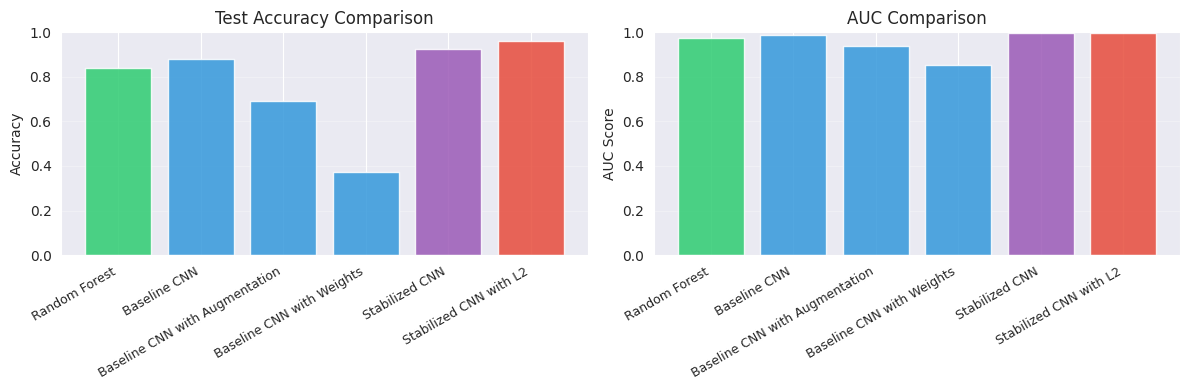


FINAL MODEL COMPARISON
Random Forest                       | Acc: 83.9% | AUC: 0.97
Baseline CNN                        | Acc: 88.2% | AUC: 0.99
Baseline CNN with Augmentation      | Acc: 69.1% | AUC: 0.94
Baseline CNN with Weights           | Acc: 37.1% | AUC: 0.85
Stabilized CNN                      | Acc: 92.5% | AUC: 1.00 | CV: 84.8% ± 0.08
Stabilized CNN with L2              | Acc: 96.0% | AUC: 1.00 | CV: 82.3% ± 0.13


In [21]:
# ============================================================================
# FINAL MODEL COMPARISON
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------------
# MODEL RESULTS
# ---------------------------------------------------------------------------
models = ['Random Forest','Baseline CNN','Baseline CNN with Augmentation','Baseline CNN with Weights','Stabilized CNN','Stabilized CNN with L2']

test_acc = [rf_test_acc, test_acc1, test_acc2, test_acc3, test_acc4, test_acc5]

auc_scores = [rf_auc_macro, auc1_macro, auc2_macro, auc3_macro, auc4_macro, auc5_macro]

# Cross-validation results (only for stabilized models)
cv_results = {
    "Stabilized CNN": (mean_acc_1, std_acc_1),
    "Stabilized CNN with L2": (mean_acc_2, std_acc_2)
}

# ---------------------------------------------------------------------------
# PLOTTING
# ---------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(models))

colors = [
    '#2ecc71',  # Random Forest
    '#3498db',
    '#3498db',
    '#3498db',
    '#9b59b6',  # Stabilized CNN
    '#e74c3c'   # Stabilized CNN + L2
]

# Accuracy plot
ax1.bar(x, test_acc, color=colors, alpha=0.85)
ax1.set_ylabel('Accuracy')
ax1.set_title('Test Accuracy Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
ax1.set_ylim([0.0, 1.0])
ax1.grid(axis='y', alpha=0.3)

# AUC plot
ax2.bar(x, auc_scores, color=colors, alpha=0.85)
ax2.set_ylabel('AUC Score')
ax2.set_title('AUC Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
ax2.set_ylim([0.0, 1.0])
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# ---------------------------------------------------------------------------
# SUMMARY
# ---------------------------------------------------------------------------
print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

for i, m in enumerate(models):

    cv_info = ""
    if m in cv_results:
        mean, std = cv_results[m]
        cv_info = f" | CV: {mean:.1%} ± {std:.2f}"

    print(f"{m:35s} | Acc: {test_acc[i]:.1%} | AUC: {auc_scores[i]:.2f}{cv_info}")

print("="*60)

# Final Discussion and Conclusion

From the comparison of all models, several clear observations can be made:

- The Random Forest baseline performs reasonably well, but it is limited because it cannot capture spatial patterns in images.
- The baseline CNN improves performance significantly by learning spatial features through convolution layers.
- Data augmentation did not improve performance in this case, which may be due to the dataset size or the added complexity in training.
- Using class weights led to a drop in performance, suggesting that class imbalance may not be a major issue or may require further tuning.
- The stabilized CNN achieved strong performance by improving feature learning and training stability.
- Adding L2 regularization further improved generalization, resulting in the best overall performance (96% test accuracy).

Overall, CNN-based models clearly outperform traditional machine learning approaches for this image classification task. However, techniques like augmentation and class weighting need careful tuning, as they do not always lead to improvements depending on the dataset.